In [70]:
#pip install bathyreq
#%pip install cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 5.8 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [77]:
import bathyreq
from adjustText import adjust_text
import numpy as np
from pyproj import Proj
from pyproj import Geod
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter
import json
import cmocean as cm
from matplotlib.colors import LogNorm
with open('PB2002_boundaries.json', 'r') as f:
    plate_boundaries = json.load(f)
from matplotlib.colors import LinearSegmentedColormap

In [83]:
def truncate_colormap(cmap_name, minval=0.0, maxval=1.0, n=256):
    """Return a truncated colormap without the lightest/darkest parts."""
    cmap = plt.get_cmap(cmap_name)
    new_colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list(f"trunc({cmap_name},{minval:.2f},{maxval:.2f})", new_colors)

# Example: remove top 30% (lightest colors) from 'Blues'
trunc_bone = truncate_colormap('bone', 0.0, 0.85)

In [91]:
stations = [{"id": "B01",   "lat": 16.0, "lon": 149.3, "tremors": 0,  "start_year": 2012, "depth": 5321, "note": 'bottom currents, ratio <6'},
            {"id": "B02",   "lat": 16.5, "lon": 148.3, "tremors": 63, "start_year": 2012, "depth": 5811, "note": 'tremor-y & t-phase', "cruise": True},
            {"id": "B03",   "lat": 16.2, "lon": 148.0, "tremors": 0,  "start_year": 2012, "depth": 5443, "note": 'tremor?, low ratio', "cruise": True},
            {"id": "B04",   "lat": 16.5, "lon": 147.5, "tremors": 0,  "start_year": 2012, "depth": 4844, "note": 'bottom currents'},
            {"id": "B05",   "lat": 16.7, "lon": 147.0, "tremors": 15, "start_year": 2012, "depth": 3813, "note": 'tremor-y', "cruise": True},
            {"id": "B06",   "lat": 17.2, "lon": 146.8, "tremors": 0,  "start_year": 2012, "depth": 3864, "note": 'bottom currents'},
            {"id": "B07",   "lat": 17.2, "lon": 147.6, "tremors": 0,  "start_year": 2012, "depth": 4285, "note": 'weird, not tremor'},
            {"id": "B08",   "lat": 17.4, "lon": 148.2, "tremors": 0,  "start_year": 2012, "depth": 4191, "note": 'bottom currents', "cruise": True, "color": 'cyan'},
            {"id": "B09",   "lat": 17.0, "lon": 148.2, "tremors": 40, "start_year": 2012, "depth": 5897, "note": 'tremor-y & t-phase', "cruise": True, "color": 'cyan'},
            {"id": "B10",   "lat": 16.8, "lon": 149.6, "tremors": 9,  "start_year": 2012, "depth": 5393, "note": 'tremor-y'},
            {"id": "B11",   "lat": 17.6, "lon": 149.6, "tremors": 0, "start_year": 2012, "depth": 5196, "note": 'whale (isabelle confirmed)'},
            {"id": "B12",   "lat": 17.6, "lon": 148.6, "tremors": 45, "start_year": 2012, "depth": 5909, "note": 'currents, whales, tremor?', "cruise": True},
            {"id": "B13",   "lat": 17.9, "lon": 147.5, "tremors": 0, "start_year": 2012, "depth": 4559, "note": 'whale?'},
            {"id": "B14",   "lat": 18.0, "lon": 146.7, "tremors": 0, "start_year": 2012, "depth": 3663, "note": 'nothing'},
            {"id": "B15",   "lat": 18.6, "lon": 146.9, "tremors": 2, "start_year": 2012, "depth": 3649, "note": 'bottom currents'},
            {"id": "B16",   "lat": 18.2, "lon": 147.5, "tremors": 0, "start_year": 2012, "depth": 5014, "note": 'nothing'},
            {"id": "B17",   "lat": 18.4, "lon": 147.9, "tremors": 0, "start_year": 2012, "depth": 4381, "note": 'nothing'},
            {"id": "B18",   "lat": 18.7, "lon": 148.5, "tremors": 1, "start_year": 2012, "depth": 5671, "note": 'bottom currents'},
            {"id": "B19",   "lat": 18.1, "lon": 148.5, "tremors": 61, "start_year": 2012, "depth": 5949, "note": 'currents, whales, tremor?'},
            {"id": "B20",   "lat": 18.5, "lon": 149.5, "tremors": 0, "start_year": 2012, "depth": 5563, "note": 'short duration events'},
            {"id": "OBS09", "lat": 16.6, "lon": 147.2, "tremors": 34,  "start_year": 2003, "depth": 3334, "note": 'tremor-y', "color": 'gold'},
            {"id": "OBS08", "lat": 16.5, "lon": 147.1, "tremors": 0,  "start_year": 2003, "depth": 3541, "note": 'tremor-y, ratio <10', "color": 'gold'},
            {"id": "OBS14", "lat": 17.7, "lon": 144.8, "tremors": 1,  "start_year": 2003, "depth": 3671, "note": 'tremor-y'},
            {"id": "OBS19", "lat": 17.9, "lon": 145.7, "tremors": 0,  "start_year": 2003, "depth": 2882, "note": 'tremor-y'},
            {"id": "OBS23", "lat": 18.0, "lon": 146.7, "tremors": 70,  "start_year": 2003, "depth": 3491, "note": 'tremor-y'},
            {"id": "OBS28", "lat": 17.9, "lon": 144.8, "tremors": 27,  "start_year": 2003, "depth": 4624, "note": 'tremor-y'},
            {"id": "OBS32", "lat": 18.1, "lon": 144.9, "tremors": 0,  "start_year": 2003, "depth": 3565, "note": 'bottom currents'},
            {"id": "OBS33", "lat": 17.9, "lon": 144.2, "tremors": 125,  "start_year": 2003, "depth": 3847, "note": 'noise, instrusment'},
            {"id": "OBS36", "lat": 18.1, "lon": 145.4, "tremors": 36,  "start_year": 2003, "depth": 3176, "note": ''},
            {"id": "OBS44", "lat": 18.3, "lon": 145.6, "tremors": 15,  "start_year": 2003, "depth": 2585, "note": ''},
            {"id": "OBS47", "lat": 18.3, "lon": 145.8, "tremors": 108,  "start_year": 2003, "depth": 1898, "note": ''},
            {"id": "OBS48", "lat": 18.1, "lon": 145.9, "tremors": 32,  "start_year": 2003, "depth": 2247, "note": ''},
            {"id": "OBS49", "lat": 18.0, "lon": 145.8, "tremors": 98,  "start_year": 2003, "depth": 2287, "note": ''},
            #{"id": "Zealandia", "lat": 16.9, "lon": 145.9, "tremors": None},
            #{"id": "Offshore", "lat": 17.5, "lon": 149.6, "tremors": None}
            ]

print(len(stations))

33


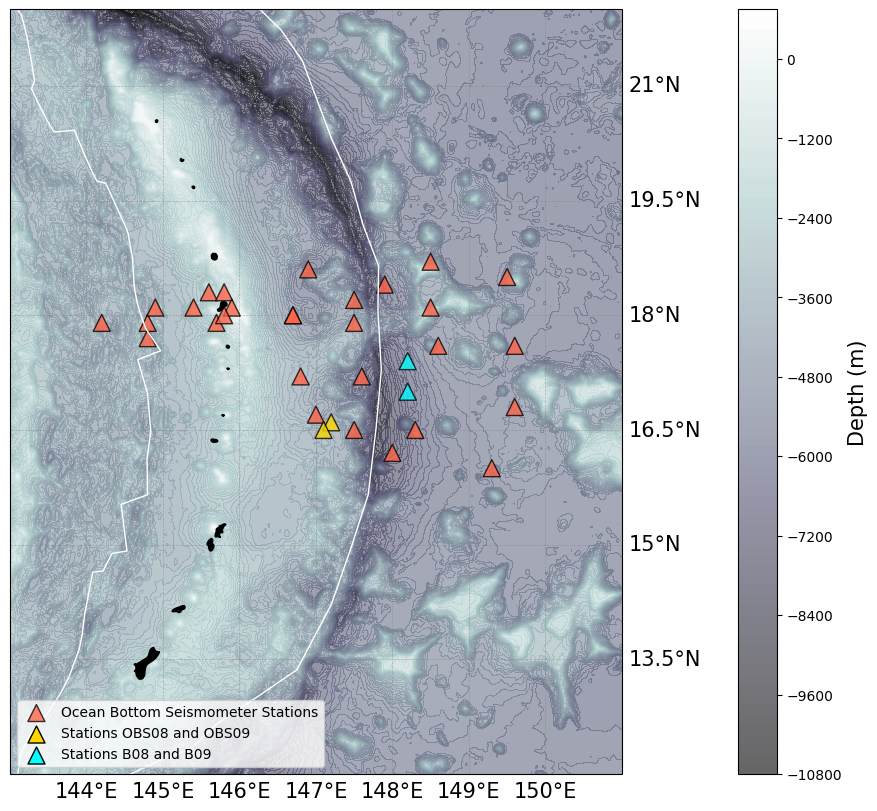

In [92]:
# INITIALIZE MAP
fig = plt.figure(figsize=[10,8], constrained_layout=True)
ax = fig.add_subplot(projection=ccrs.PlateCarree(central_longitude=0))
ax.set_extent([151, 143, 22, 12], crs=ccrs.PlateCarree())

# ADD BATHY
req = bathyreq.BathyRequest()
data, lonvec, latvec = req.get_area(longitude=[151, 143], latitude=[12, 22])
# 2-D coordinate grid
lon_b, lat_b = np.meshgrid(lonvec, latvec)
# plot bathy
bathy = ax.contourf(lon_b, lat_b, data, levels=100, cmap="bone", transform=ccrs.PlateCarree(), alpha=0.6)
bathy_cb = plt.colorbar(bathy, ax=ax)
bathy_cb.set_label("Depth (m)", size = 15)

# ADD GRIDLINES
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = True
gl.left_labels = False
gl.bottom_labels = True
gl.xlabel_style = {'size': 15}
gl.ylabel_style = {'size': 15}

ax.add_feature(cfeature.LAND, facecolor='black', zorder = 3) 
ax.coastlines()

# ADD STATIONS & TREMOR COUNT
lon = np.array([s["lon"] for s in stations])
lat = np.array([s["lat"] for s in stations])
#tremor = np.array([s["tremors"] for s in stations])

colors = [s.get("color", "tomato") for s in stations]
ax.scatter(lon, lat,c=colors,marker="^",s=150,alpha=0.78,edgecolor="black",transform=ccrs.PlateCarree(),zorder=2,label="Ocean Bottom Seismometer Stations")
ax.scatter([], [],c="gold",marker="^",s=150,edgecolor="black",label="Stations OBS08 and OBS09")
ax.scatter([], [],c="cyan",marker="^",s=150,edgecolor="black",label="Stations B08 and B09")

'''
# add transect 
lat1, lon1 = 
lat2, lon2 = 


geod = Geod(ellps="WGS84")

points = 200  
pts = geod.npts(lon1, lat1, lon2, lat2, points)
intermediate_lons, intermediate_lats = zip(*pts)
lons = np.array([lon1] + list(intermediate_lons) + [lon2])
lats = np.array([lat1] + list(intermediate_lats) + [lat2])

ax.plot(lons, lats,color="yellow",linewidth=2.5,transform=ccrs.PlateCarree(),zorder=4,label="Transect Line")
'''
ax.legend(loc='lower left')

#cbar = plt.colorbar(scatter, ax=ax, orientation="vertical", shrink=0.7) 
#cbar.set_label("Tremor-like Signals", size = 15)

'''
for s in stations:
    marker = "*" if s.get("cruise") else "^"
    ax.scatter(
        s["lon"], s["lat"],
        marker=marker,
        s=150,
        edgecolor="black",
        facecolor="yellow" if s.get("cruise") else "red",
        transform=ccrs.PlateCarree(),
        zorder=5
    )


texts = [] 
for s in stations: 
    t = ax.text( s["lon"] + 0.05, s["lat"] + 0.05, s["note"], fontsize=9, transform=ccrs.PlateCarree(), zorder=20 ) 
    texts.append(t)
'''   
#adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray'))
#ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.8)

# PLOT TECTONIC BOUNDARIES
for feature in plate_boundaries['features']:
    coords = feature['geometry']['coordinates']
    if feature['geometry']['type'] == 'LineString':
        lons, lats = zip(*coords)
        ax.plot(lons, lats, color='white', linewidth=1, transform=ccrs.PlateCarree())
    elif feature['geometry']['type'] == 'MultiLineString':
        for line in coords:
            lons, lats = zip(*line)
            ax.plot(lons, lats, color='white', linewidth=1, transform=ccrs.PlateCarree())

# --- Legend and Save ---
#plt.savefig("map.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [87]:
stations = [{"id": "J18B", "lat": 44.0, "lon": -125.5, "tremors": 835, "start_year": 2012, "depth": 3047},
            {"id": "J10B", "lat": 43.3, "lon": -125.5, "tremors": 811, "start_year": 2012, "depth": 3093},
            {"id": "G34B", "lat": 42.6, "lon": -125.2, "tremors": 0, "start_year": 2012, "depth": 2954},
            {"id": "G26B", "lat": 41.9, "lon": -125.2, "tremors": 0, "start_year": 2012, "depth": 2357},
            {"id": "J67C", "lat": 48.2, "lon": -127.1, "tremors": 155, "start_year": 2013, "depth": 2581},
            {"id": "J26C", "lat": 44.7, "lon": -125.5, "tremors": 0, "start_year": 2013, "depth": 2868},
            {"id": "J34C", "lat": 45.3, "lon": -125.4, "tremors": 0, "start_year": 2013, "depth": 2580},
            {"id": "J51C", "lat": 46.8, "lon": -126.2, "tremors": 0, "start_year": 2013, "depth": 2626},
            {"id": "J10D", "lat": 43.3, "lon": -125.5, "tremors": 1301, "start_year": 2014, "depth": 3085},
            {"id": "J26D", "lat": 44.7, "lon": -125.5, "tremors": 1056, "start_year": 2014, "depth": 2880},
            {"id": "J18D", "lat": 43.9, "lon": -125.5, "tremors": 1165, "start_year": 2014, "depth": 3050},
            {"id": "G34D", "lat": 42.6, "lon": -125.4, "tremors": 135, "start_year": 2014, "depth": 3089},
            {"id": "G26D", "lat": 41.9, "lon": -125.3, "tremors": 0, "start_year": 2014, "depth": 3104},
            {"id": "G18D", "lat": 41.3, "lon": -125.3, "tremors": 0, "start_year": 2014, "depth": 3130},
            {"id": "NCBC", "lat": 48.4, "lon": -126.2, "tremors": 1, "start_year": 2009, "depth": 398, "color": 'cyan'},
            {"id": "NC89", "lat": 48.75, "lon": -126.9, "tremors": 70, "start_year": 2009, "depth": 1258, "color": 'gold'},
            {"id": "M01C", "lat": 49.2, "lon": -126.7, "tremors": 0, "start_year": 2013, "depth": 138},
            {"id": "J73C", "lat": 48.8, "lon": -126.2, "tremors": 0, "start_year": 2013, "depth": 133},
            {"id": "M02C", "lat": 48.3, "lon": -125.6, "tremors": 21, "start_year": 2013, "depth": 141},
            {"id": "M03C", "lat": 47.9, "lon": -125.1, "tremors": 3998, "start_year": 2013, "depth": 1839},
            {"id": "M04C", "lat": 47.6, "lon": -125.2, "tremors": 16, "start_year": 2013, "depth": 570},
            {"id": "J65C", "lat": 48.0, "lon": -125.1, "tremors": 1714, "start_year": 2013, "depth": 169},
            {"id": "J59C", "lat": 47.5, "lon": -126.4, "tremors": 3, "start_year": 2013, "depth": 2389},
            {"id": "J58C", "lat": 47.3, "lon": -125.5, "tremors": 900, "start_year": 2013, "depth": 1527},
            {"id": "FN16C", "lat": 46.8, "lon": -125.53, "tremors": 0, "start_year": 2013, "depth": 1728},
            {"id": "FN11C", "lat": 46.8, "lon": -125.1, "tremors": 1, "start_year": 2013, "depth": 691},
            {"id": "FN17C", "lat": 46.7, "lon": -125.0, "tremors": 0, "start_year": 2013, "depth": 1015},
            {"id": "J49C", "lat": 46.4, "lon": -124.4, "tremors": 0, "start_year": 2013, "depth": 113},
            {"id": "M05C", "lat": 46.2, "lon": -124.9, "tremors": 2456, "start_year": 2013, "depth": 837},
            {"id": "J42C", "lat": 45.9, "lon": -125.3, "tremors": 10, "start_year": 2013, "depth": 1550},
            {"id": "J41C", "lat": 45.8, "lon": -124.5, "tremors": 0, "start_year": 2013, "depth": 171},
            {"id": "M06C", "lat": 45.5, "lon": -124.9, "tremors": 378, "start_year": 2013, "depth": 1460},
            {"id": "J33B", "lat": 45.1, "lon": -124.6, "tremors": 36, "start_year": 2012, "depth": 350},
            {"id": "M07C", "lat": 44.9, "lon": -125.1, "tremors": 0, "start_year": 2013, "depth": 1365},
            {"id": "M18B", "lat": 44.9, "lon": -125.0, "tremors": 0, "start_year": 2012, "depth": 720},
            {"id": "FC03D", "lat": 44.8, "lon": -124.7, "tremors": 0, "start_year": 2014, "depth": 432},
            {"id": "J25C", "lat": 44.5, "lon": -124.6, "tremors": 0, "start_year": 2013, "depth": 144},
            {"id": "J25B", "lat": 44.5, "lon": -124.6, "tremors": 0, "start_year": 2012, "depth": 147},
            {"id": "J25D", "lat": 44.5, "lon": -124.6, "tremors": 0, "start_year": 2014, "depth": 136},
            {"id": "M09B", "lat": 44.2, "lon": -125.1, "tremors": 8, "start_year": 2012, "depth": 914},
            {"id": "M08C", "lat": 44.1, "lon": -124.9, "tremors": 14, "start_year": 2013, "depth": 131},
            {"id": "J17D", "lat": 43.8, "lon": -124.6, "tremors": 12, "start_year": 2014, "depth": 285},
            {"id": "M10B", "lat": 43.6, "lon": -125.0, "tremors": 0, "start_year": 2012, "depth": 675},
            {"id": "M13D", "lat": 43.6, "lon": -125.0, "tremors": 0, "start_year": 2014, "depth": 990},
            {"id": "J09B", "lat": 43.2, "lon": -124.7, "tremors": 12, "start_year": 2012, "depth": 252},
            {"id": "M11B", "lat": 42.9, "lon": -125.0, "tremors": 6367, "start_year": 2012, "depth": 1109},
            {"id": "M14D", "lat": 42.6, "lon": -125.0, "tremors": 13, "start_year": 2014, "depth": 997},
            {"id": "G33D", "lat": 42.7, "lon": -124.8, "tremors": 7201, "start_year": 2014, "depth": 686},
            {"id": "G33B", "lat": 42.5, "lon": -124.7, "tremors": 0, "start_year": 2012, "depth": 213},
            {"id": "M15D", "lat": 42.2, "lon": -124.9, "tremors": 0, "start_year": 2014, "depth": 933},
            {"id": "M12B", "lat": 42.2, "lon": -124.9, "tremors": 15632, "start_year": 2012, "depth": 1045},
            {"id": "G25B", "lat": 41.9, "lon": -124.6, "tremors": 0, "start_year": 2012, "depth": 430},
            {"id": "M13B", "lat": 41.7, "lon": -124.9, "tremors": 0, "start_year": 2012, "depth": 909},
            {"id": "M16D", "lat": 41.7, "lon": -124.8, "tremors": 0, "start_year": 2014, "depth": 882},
            {"id": "G18B", "lat": 41.3, "lon": -124.9, "tremors": 71, "start_year": 2012, "depth": 1464},
            {"id": "G17D", "lat": 41.4, "lon": -124.4, "tremors": 0, "start_year": 2014, "depth": 99},
            {"id": "G17B", "lat": 41.3, "lon": -124.3, "tremors": 36, "start_year": 2012, "depth": 123},
            {"id": "M17D", "lat": 41.0, "lon": -124.6, "tremors": 9, "start_year": 2014, "depth": 749},
            {"id": "M14B", "lat": 41.0, "lon": -124.6, "tremors": 838, "start_year": 2012, "depth": 638},
            {"id": "BACND", "lat": 48.3, "lon": -126.2, "tremors": 5151, "start_year": 2018, "depth": 643},
            {"id": "BACME", "lat": 48.3, "lon": -126.1, "tremors": 43, "start_year": 2016, "depth": 897, "color": 'cyan'},
            {"id": "CQS64", "lat": 48.7, "lon": -126.9, "tremors": 0, "start_year": 2016, "depth": 1323, "color": 'gold'},
            {"id": "FN13C", "lat": 47.0, "lon": -125.3, "tremors": 4010, "start_year": 2013, "depth": 1764},
            {"id": "FN12C", "lat": 46.9, "lon": -125.1, "tremors": 0, "start_year": 2013, "depth": 656},
            {"id": "FN14C", "lat": 47.0, "lon": -125.0, "tremors": 3, "start_year": 2013, "depth": 173},
            {"id": "FN10C", "lat": 46.9, "lon": -125.0, "tremors": 175, "start_year": 2013, "depth": 811},
            {"id": "FN08C", "lat": 46.9, "lon": -124.9, "tremors": 0, "start_year": 2013, "depth": 176},
            {"id": "FN09C", "lat": 46.8, "lon": -124.9, "tremors": 0, "start_year": 2013, "depth": 198},
            {"id": "FN07C", "lat": 46.9, "lon": -124.8, "tremors": 1, "start_year": 2013, "depth": 158},
            {"id": "FN06C", "lat": 46.9, "lon": -124.7, "tremors": 0, "start_year": 2013, "depth": 137},
            {"id": "FN04C", "lat": 46.9, "lon": -124.6, "tremors": 89, "start_year": 2013, "depth": 104},
            {"id": "FN03C", "lat": 46.9, "lon": -124.5, "tremors": 11, "start_year": 2013, "depth": 93},
            {"id": "FN05C", "lat": 46.9, "lon": -124.7, "tremors": 15, "start_year": 2013, "depth": 123},
            {"id": "J57C", "lat": 47.1, "lon": -124.5, "tremors": 0, "start_year": 2013, "depth": 67},
            {"id": "FN02C", "lat": 46.9, "lon": -124.4, "tremors": 31, "start_year": 2013, "depth": 67},
            {"id": "FN01C", "lat": 46.9, "lon": -124.3, "tremors": 0, "start_year": 2013, "depth": 56},
            {"id": "FN19C", "lat": 46.7, "lon": -124.4, "tremors": 183, "start_year": 2013, "depth": 72},
            {"id": "FN17C", "lat": 46.7, "lon": -125.0, "tremors": 0, "start_year": 2013, "depth": 1015},
            {"id": "FN18C", "lat": 46.7, "lon": -124.7, "tremors": 1, "start_year": 2013, "depth": 166},
            {"id": "J53C", "lat": 47.2, "lon": -127.9, "tremors": 0, "start_year": 2013, "depth": 2717},
            {"id": "J35C", "lat": 45.5, "lon": -126.3, "tremors": 0, "start_year": 2013, "depth": 2655},
            {"id": "J46C", "lat": 46.7, "lon": -128.8, "tremors": 0, "start_year": 2013, "depth": 2744},
            #{"id": "HYSB1", "lat": 44.5, "lon": -125.4, "tremors": 1, "start_year": 2014, "depth": 2909}
           ]
print(len(stations))

82


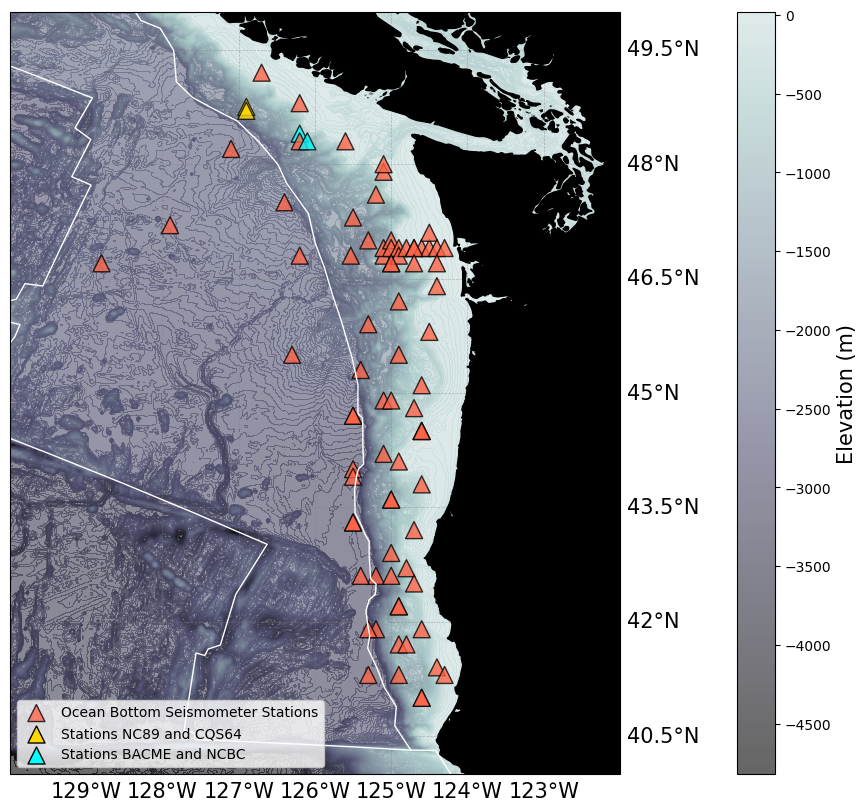

In [89]:
# INITIALIZE MAP
fig = plt.figure(figsize=[10,8], constrained_layout=True)
ax = fig.add_subplot(projection=ccrs.PlateCarree(central_longitude=0))
ax.set_extent([-130, -122, 40, 50], crs=ccrs.PlateCarree())

# ADD BATHY
req = bathyreq.BathyRequest()
data, lonvec, latvec = req.get_area(longitude=[-130, -122], latitude=[40, 50])
data = np.flipud(data)
data = np.minimum(data, 10)
# 2-D coordinate grid
lon_b, lat_b = np.meshgrid(lonvec, latvec)

# plot bathy
bathy = ax.contourf(lon_b, lat_b, data, levels=300, cmap=trunc_bone, transform=ccrs.PlateCarree(), alpha=0.6)
bathy_cb = plt.colorbar(bathy, ax=ax)
bathy_cb.set_label("Elevation (m)", size = 15)

# ADD GRIDLINES
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = True
gl.left_labels = False
gl.bottom_labels = True
gl.xlabel_style = {'size': 15}
gl.ylabel_style = {'size': 15}

ax.add_feature(cfeature.LAND, facecolor='black', zorder = 3) 
ax.coastlines()

# ADD STATIONS & TREMOR COUNT
lon = np.array([s["lon"] for s in stations])
lat = np.array([s["lat"] for s in stations])
'''
tremor = np.array([s["tremors"] for s in stations])

#mask for high tremor counts
mask_hi = tremor > 300
mask_lo = tremor <= 300

scatter = ax.scatter(lon[mask_lo], lat[mask_lo], c=tremor[mask_lo], cmap="magma_r", marker="^", s=150, alpha=0.78, edgecolor="black", transform=ccrs.PlateCarree(), zorder=2)
cbar = plt.colorbar(scatter, ax=ax, orientation="vertical", shrink=0.7) 
cbar.set_label("Tremor-like Signals", size = 15)
ax.scatter( lon[mask_hi], lat[mask_hi], color="cyan", marker="^", s=180, edgecolor="black", linewidth=1.2, alpha=0.95, transform=ccrs.PlateCarree(), zorder=3, label="Tremor-like signals > 300")
ax.legend(loc="upper right")
'''
colors = [s.get("color", "tomato") for s in stations]
ax.scatter(lon, lat,c=colors,marker="^",s=150,alpha=0.78,edgecolor="black",transform=ccrs.PlateCarree(),zorder=2,label="Ocean Bottom Seismometer Stations")
ax.scatter([], [],c="gold",marker="^",s=150,edgecolor="black",label="Stations NC89 and CQS64")
ax.scatter([], [],c="cyan",marker="^",s=150,edgecolor="black",label="Stations BACME and NCBC")
'''
# add transect 
lat1, lon1 = 48.43, -126.02
lat2, lon2 = 48.54, -126.07 


geod = Geod(ellps="WGS84")

points = 200  
pts = geod.npts(lon1, lat1, lon2, lat2, points)
intermediate_lons, intermediate_lats = zip(*pts)
lons = np.array([lon1] + list(intermediate_lons) + [lon2])
lats = np.array([lat1] + list(intermediate_lats) + [lat2])

ax.plot(lons, lats,color="yellow",linewidth=2.5,transform=ccrs.PlateCarree(),zorder=4,label="Transect Line")
'''
ax.legend(loc='lower left')

'''
texts = [] 
for s in stations: 
    t = ax.text( s["lon"] + 0.05, s["lat"] + 0.05, s["note"], fontsize=9, transform=ccrs.PlateCarree(), zorder=20 ) 
    texts.append(t)
'''   
#adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray'))
#ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.8)

# PLOT TECTONIC BOUNDARIES
for feature in plate_boundaries['features']:
    coords = feature['geometry']['coordinates']
    if feature['geometry']['type'] == 'LineString':
        lons, lats = zip(*coords)
        ax.plot(lons, lats, color='white', linewidth=1, transform=ccrs.PlateCarree())
    elif feature['geometry']['type'] == 'MultiLineString':
        for line in coords:
            lons, lats = zip(*line)
            ax.plot(lons, lats, color='white', linewidth=1, transform=ccrs.PlateCarree())

# --- Legend and Save ---
#plt.savefig("map.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()
